In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# INSTALL + IMPORT
# =========================
!pip install ultralytics -q

from ultralytics import YOLO
import torch
import shutil
import os

# =========================
# CHECK GPU
# =========================
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# =========================
# PATHS (FIXED)
# =========================
DATA_YAML = "/content/drive/MyDrive/mvp-1/data/data-colab.yaml"

RUNS_DIR = "/content/drive/MyDrive/mvp-1/runs"
MODEL_SAVE_DIR = "/content/drive/MyDrive/mvp-1/model_yolo_alignment"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# =========================
# VERIFY PATH (IMPORTANT)
# =========================
if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"❌ YAML not found at {DATA_YAML}")
else:
    print("✅ YAML found")

# =========================
# LOAD MODEL
# =========================
model = YOLO("yolov8s.pt")

# =========================
# TRAIN
# =========================
results = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=832,
    batch=16,
    device=0,
    workers=2,

    project=RUNS_DIR,
    name="crane_alignment_colab",

    optimizer="AdamW",
    lr0=0.001,
    patience=10,

    # alignment-focused tuning
    box=10.0,
    cls=0.5,
    dfl=1.5,

    # valid augmentations
    degrees=5,
    scale=0.3,
    shear=0.0,
    perspective=0.0,
    hsv_v=0.4,

    close_mosaic=10,
    verbose=True
)

# =========================
# SAVE BEST MODEL TO DRIVE
# =========================
best_model_path = f"{RUNS_DIR}/crane_alignment_colab/weights/best.pt"
final_model_path = f"{MODEL_SAVE_DIR}/best_yolo_alignment.pt"

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, final_model_path)
    print(f"✅ Best model saved to: {final_model_path}")
else:
    print("❌ best.pt not found")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4
✅ YAML found
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/mvp-1/data/data-colab.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False,

GPU: Tesla T4
✅ YAML found
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/mvp-1/data/data-colab.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=832, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=crane_alignment_colab-4, nbs=64, nms=False, opset=None, op

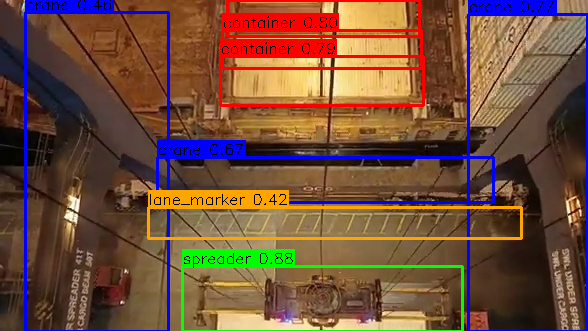

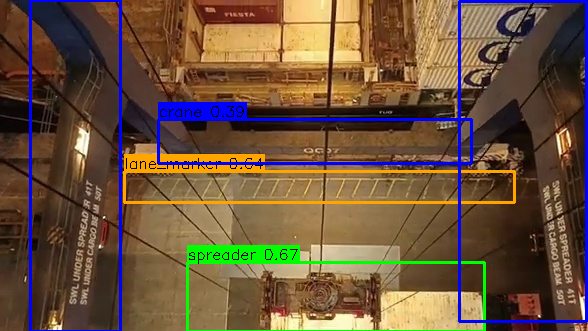

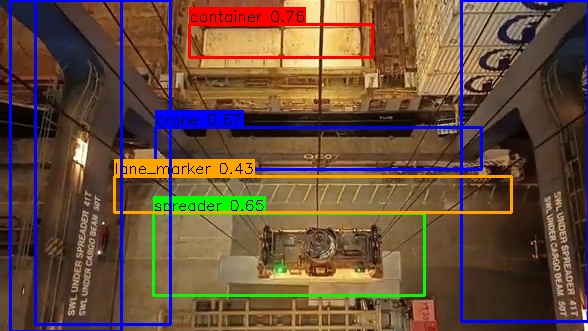

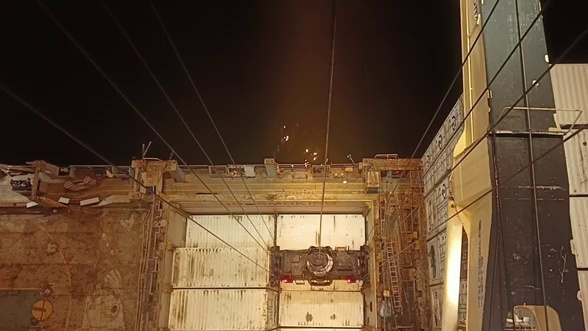

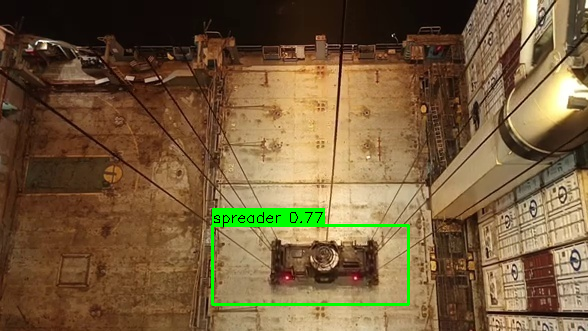


📂 Predictions saved at: /content/drive/MyDrive/mvp-1/predictions


In [ ]:
# Train and Visualize -20/04/2026

# =========================
# INSTALL + IMPORT
# =========================
!pip install ultralytics -q

from ultralytics import YOLO
import torch
import shutil
import os
import cv2
import random
from glob import glob
from IPython.display import display
from PIL import Image

# =========================
# CHECK GPU
# =========================
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# =========================
# PATHS
# =========================
DATA_YAML = "/content/drive/MyDrive/mvp-1/data/data-colab.yaml"
RUNS_DIR = "/content/drive/MyDrive/mvp-1/runs"
MODEL_SAVE_DIR = "/content/drive/MyDrive/mvp-1/model_yolo_alignment"
PRED_DIR = "/content/drive/MyDrive/mvp-1/predictions"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# =========================
# VERIFY PATH
# =========================
if not os.path.exists(DATA_YAML):
    raise FileNotFoundError(f"❌ YAML not found at {DATA_YAML}")
else:
    print("✅ YAML found")

# =========================
# LOAD MODEL
# =========================
model = YOLO("yolov8s.pt")

# =========================
# TRAIN
# =========================
results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=832,
    batch=16,
    device=0,
    workers=2,

    project=RUNS_DIR,
    name="crane_alignment_colab",

    optimizer="AdamW",
    lr0=0.001,
    patience=15,

    box=10.0,
    cls=0.5,
    dfl=1.5,

    degrees=5,
    scale=0.3,
    shear=0.0,
    perspective=0.0,
    hsv_v=0.4,

    close_mosaic=10,
    verbose=True
)

# =========================
# SAVE BEST MODEL
# =========================
best_model_path = f"{RUNS_DIR}/crane_alignment_colab/weights/best.pt"
final_model_path = f"{MODEL_SAVE_DIR}/best_yolo_alignment.pt"

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, final_model_path)
    print(f"✅ Best model saved to: {final_model_path}")
else:
    raise FileNotFoundError("❌ best.pt not found")

# =========================
# CLASS COLORS (BGR)
# =========================
CLASS_COLORS = {
    0: (255, 0, 0),     # crane
    1: (0, 255, 0),     # spreader
    2: (0, 255, 255),   # spreader_corner
    3: (255, 255, 0),   # hook
    4: (0, 0, 255),     # container
    5: (255, 0, 255),   # container_corner
    6: (128, 0, 255),   # AGV
    7: (0, 165, 255),   # lane_marker
}

# =========================
# LOAD VAL IMAGES
# =========================
VAL_IMG_DIR = os.path.join(os.path.dirname(DATA_YAML), "images/val")

image_paths = glob(os.path.join(VAL_IMG_DIR, "*.jpg"))
sample_images = random.sample(image_paths, min(10, len(image_paths)))

print(f"🔍 Visualizing {len(sample_images)} validation samples...")

# =========================
# CUSTOM DRAW FUNCTION
# =========================
def draw_predictions(img, result):
    boxes = result.boxes

    for box in boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        color = CLASS_COLORS.get(cls, (255, 255, 255))
        label = f"{model.names[cls]} {conf:.2f}"

        # box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # text background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - 5), (x1 + tw, y1), color, -1)

        # text
        cv2.putText(img, label, (x1, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    return img

# =========================
# RUN INFERENCE + DISPLAY
# =========================
for i, img_path in enumerate(sample_images):

    results = model.predict(img_path, conf=0.3, verbose=False)

    img = cv2.imread(img_path)

    img = draw_predictions(img, results[0])

    save_path = os.path.join(PRED_DIR, f"pred_{i}.jpg")
    cv2.imwrite(save_path, img)

    # display in notebook
    display(Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))

print(f"\n📂 Predictions saved at: {PRED_DIR}")
